<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [2]:
# loading the data: Wholesale customers data
df = pd.read_csv("../data/Wholesale customers data.csv")
df.head()   # preview the first 5 rows

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [3]:
df.shape           # (rows, columns)

(440, 8)

Observations:

440 customers, 8 features — small, clean dataset ready for clustering.


In [4]:
print(df.isnull().sum())   # check how many NaNs per column

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


Observations:

440 rows × 8 columns — 440 customers, 8 financial/demographic features, no dimensionality concerns.

<Axes: >

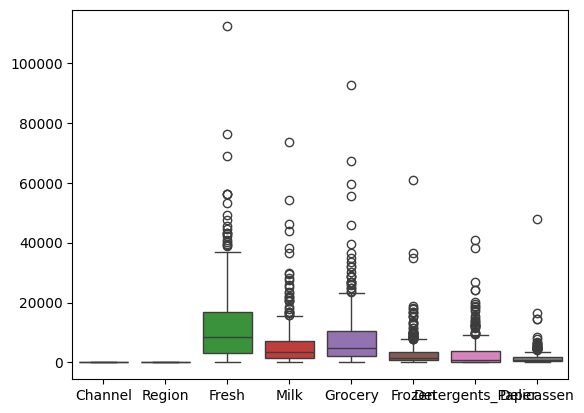

In [5]:
df.describe()
sns.boxplot(data=df)

observations:

Heavy outliers across all spending columns — Fresh, Milk, Grocery, and Detergents_Paper all show extreme high-end values well above their IQR. Channel and Region are categorical with no spread. These outliers will distort K-Means centroids and should be capped or removed before clustering.


array([[<Axes: title={'center': 'Channel'}>,
        <Axes: title={'center': 'Region'}>,
        <Axes: title={'center': 'Fresh'}>],
       [<Axes: title={'center': 'Milk'}>,
        <Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>, <Axes: >]], dtype=object)

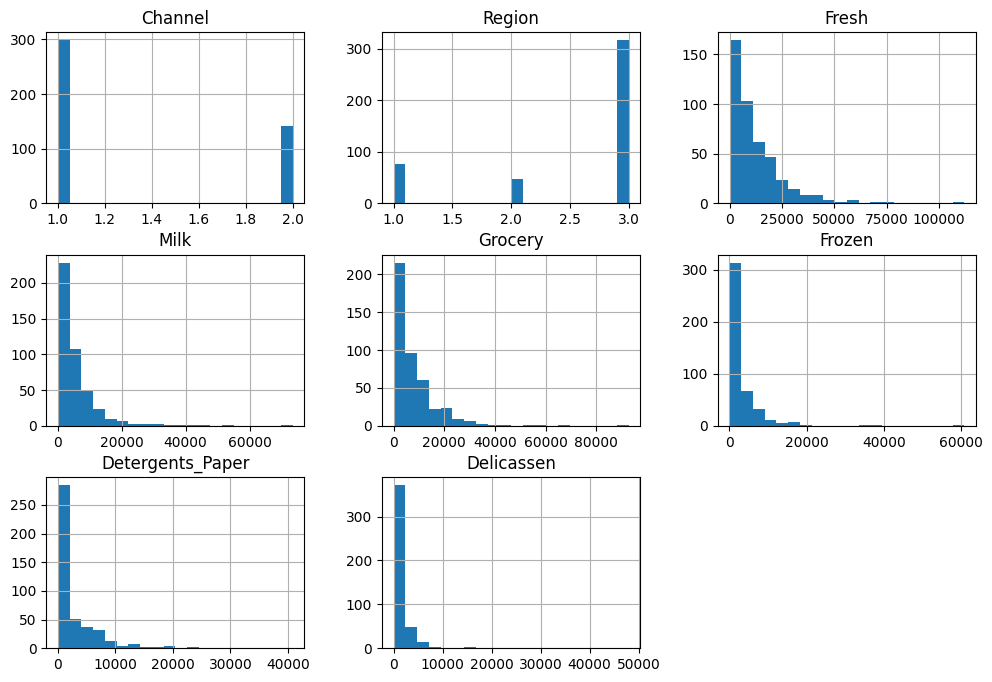

In [6]:
df.hist(bins=20, figsize=(12, 8))

Observations:

All spending columns (Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen) are heavily right-skewed — the vast majority of customers spend low amounts, with a long tail of high spenders. Channel and Region are binary/categorical as expected.

In [7]:
df.dtypes          # Data types per column

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Observations:

All 8 columns are int64 — Channel and Region should be categorical, and the spending columns should be float64

In [8]:
df.info()          # Non-null counts + dtypes

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [9]:
df.nunique()

Channel               2
Region                3
Fresh               433
Milk                421
Grocery             430
Frozen              426
Detergents_Paper    417
Delicassen          403
dtype: int64

Observations:

Channel has 2 unique values and Region has 3 — confirming they are categorical, not continuous numeric features. All spending columns have 400+ unique values, confirming they are truly continuous.
Fix — encode the categoricals before clustering



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [10]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [11]:
# Convert Channel and Region to categorical
df['Channel'] = df['Channel'].astype('category')
df['Region']  = df['Region'].astype('category')

# Spending columns will automatically become float64 after log1p
# but if not, force it manually:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df[spend_cols] = df[spend_cols].astype('float64')

# Verify
print(df.dtypes)

Channel             category
Region              category
Fresh                float64
Milk                 float64
Grocery              float64
Frozen               float64
Detergents_Paper     float64
Delicassen           float64
dtype: object


In [12]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669.0,9656.0,7561.0,214.0,2674.0,1338.0
1,2,3,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0
2,2,3,6353.0,8808.0,7684.0,2405.0,3516.0,7844.0
3,1,3,13265.0,1196.0,4221.0,6404.0,507.0,1788.0
4,2,3,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0


Before: (440, 8)
After:  (332, 8)


<Axes: >

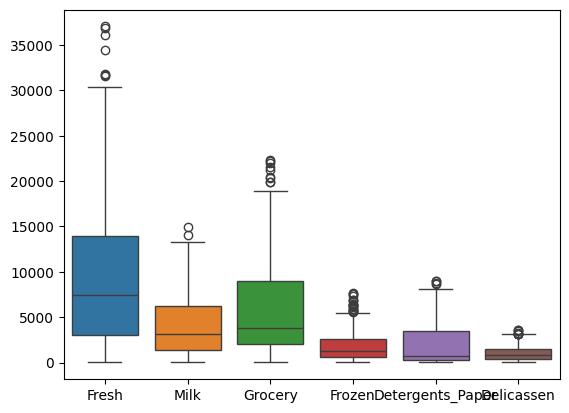

In [13]:
# Remove outliers using the IQR method for each numeric column

# Define which columns to check for outliers
# Channel and Region are categorical so we exclude them
numeric_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Calculate the 25th percentile (Q1) for each numeric column
Q1  = df[numeric_cols].quantile(0.25)

# Calculate the 75th percentile (Q3) for each numeric column
Q3  = df[numeric_cols].quantile(0.75)

# IQR = Interquartile Range = the middle 50% of the data (Q3 - Q1)
# A small IQR means data is tightly packed; a large IQR means it is spread out
IQR = Q3 - Q1

# Define outlier boundaries:
# Lower fence = Q1 - 1.5 * IQR  → anything below this is a low outlier
# Upper fence = Q3 + 1.5 * IQR  → anything above this is a high outlier

# Build a boolean mask: True where a value IS an outlier
# .any(axis=1) → flag a row if ANY of its columns is an outlier
# ~ (tilde)    → invert the mask → keep only rows with NO outliers
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Compare row counts before and after to see how many outliers were removed
print('Before:', df.shape)
print('After: ', df_clean.shape)

# Visual confirmation — boxplot should now show no (or very few) circles above/below the whiskers
sns.boxplot(data=df_clean)

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

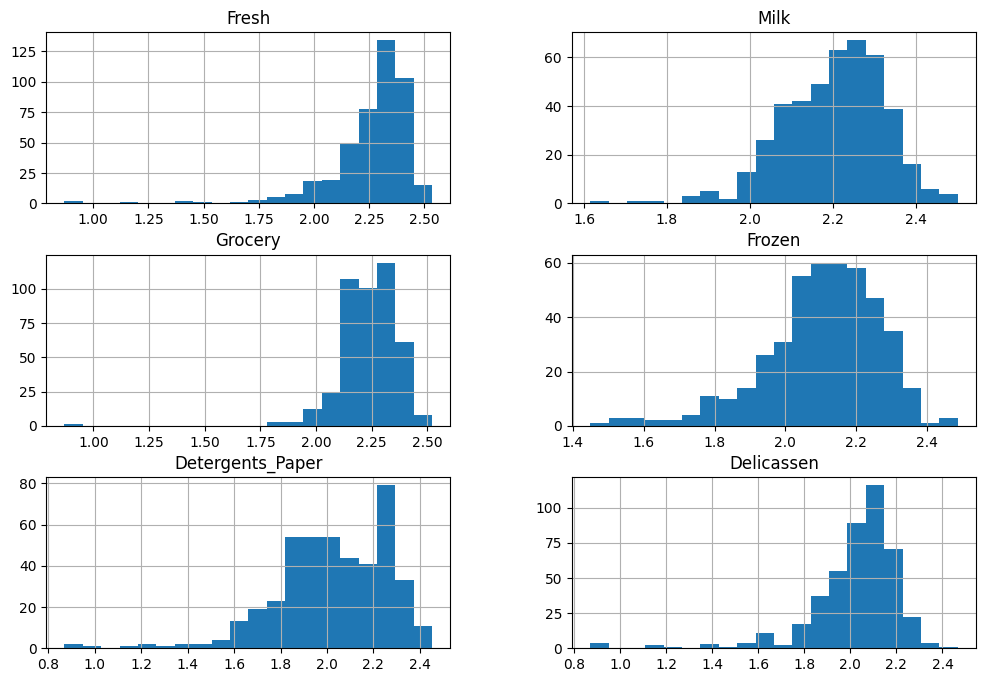

In [18]:
#apply log transformation to compress the long tail
cols_to_log = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# log1p = log(1 + x) — handles zeros safely (avoids log(0) = -inf)
df[cols_to_log] = df[cols_to_log].apply(np.log1p)

# Verify the distributions are now more normal
df.hist(bins=20, figsize=(12, 8))

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [19]:
# The problem: feature ranges are very different across columns
# For example:
#   Fresh / Grocery → values in the tens of thousands
#   Detergents_Paper / Delicassen → values in the hundreds or low thousands
# This is a problem for K-Means because it uses Euclidean distance —
# features with larger ranges will dominate and bias the clustering

# Solution: StandardScaler
# Transforms each feature so that:
#   mean  = 0  (centres the data)
#   std   = 1  (puts all features on the same scale)
# This ensures every column contributes equally to the distance calculation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform does two things:
#   1. fit:      learns the mean and std from df
#   2. transform: applies the scaling to every column
customers_scale = scaler.fit_transform(df)

# customers_scale is now a NumPy array where every feature
# has mean ≈ 0 and standard deviation ≈ 1
print('Shape:', customers_scale.shape)
print('Mean per column (should be ≈ 0):', customers_scale.mean(axis=0).round(4))
print('Std  per column (should be ≈ 1):', customers_scale.std(axis=0).round(4))


Shape: (440, 8)
Mean per column (should be ≈ 0): [ 0.  0.  0. -0.  0.  0. -0. -0.]
Std  per column (should be ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1.]


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [21]:
from sklearn.cluster import KMeans

# Step 1: Initialise the K-Means model
# n_clusters=5  → we want to find 5 customer segments
# init='k-means++' → smart centroid initialisation (better than random)
# n_init=10     → run 10 times with different seeds, keep the best result
# random_state=42 → reproducibility
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)

# Step 2: Fit the model on the scaled data
# The model finds the 5 centroids that minimise inertia (within-cluster variance)
kmeans.fit(customers_scale)

# Step 3: Extract the cluster label assigned to each customer
# labels_ is an array of length 440 — one cluster ID (0 to 4) per customer
print('Cluster labels:', kmeans.labels_)
print('Label counts:\n', pd.Series(kmeans.labels_).value_counts().sort_index())

# Step 4: Assign the cluster labels back to the original (unscaled) DataFrame
# This lets us see which segment each customer belongs to
# alongside their original spending values
df['labels'] = kmeans.labels_
# Preview the result
df.head(10)

Cluster labels: [1 1 1 2 1 1 1 1 2 1 1 2 1 1 1 2 1 2 1 2 1 2 2 1 1 1 2 2 1 2 2 2 2 2 2 1 2
 1 1 2 2 2 1 1 1 1 1 1 1 1 2 2 1 1 2 2 1 1 2 2 1 1 1 1 2 1 3 1 2 2 2 2 2 1
 1 0 2 1 2 2 2 1 1 2 1 1 1 2 0 2 0 2 1 2 1 3 3 0 0 2 1 1 1 2 2 2 1 1 1 3 2
 1 2 2 2 2 2 2 2 2 2 2 0 1 2 2 2 1 3 2 2 0 2 2 2 2 2 3 2 2 2 2 3 2 2 1 2 2
 0 2 2 2 2 2 0 1 1 2 1 1 1 0 2 1 1 1 1 2 0 2 1 1 2 1 2 1 2 2 2 2 2 2 3 2 3
 2 2 3 1 1 2 0 2 1 2 2 4 1 4 4 1 1 4 3 0 1 4 1 4 1 4 1 4 4 1 4 1 4 1 0 4 4
 4 4 4 4 1 4 4 4 4 4 4 3 4 4 4 4 0 4 4 4 4 4 4 1 4 0 4 4 4 1 4 4 4 4 4 4 4
 4 4 4 4 4 1 4 1 4 1 4 4 4 4 2 2 0 2 2 2 1 2 1 2 2 2 3 2 2 2 0 2 2 2 1 4 1
 4 1 1 3 1 1 1 1 1 1 1 4 4 1 4 4 1 4 4 1 4 4 4 1 4 4 4 4 4 4 4 0 4 4 4 1 4
 1 4 1 4 4 3 4 1 1 1 1 2 2 1 1 2 1 2 1 0 1 2 3 0 3 2 2 2 0 2 2 2 1 2 0 2 0
 1 2 2 1 2 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 0 2 2 2 2 2 2 2 2
 1 1 2 2 2 3 2 2 1 1 2 1 2 1 1 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 2 3]
Label counts:
 0     25
1    137
2    178
3     19
4     81
Name: count, dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
0,2,3,2.346314,2.319977,2.295650,1.851700,2.185119,2.104095,1
1,2,3,2.288681,2.321530,2.319077,2.137094,2.208259,2.138027,1
2,2,3,2.277969,2.310903,2.297274,2.173128,2.215432,2.299343,1
3,1,3,2.350705,2.090329,2.235169,2.278788,1.978306,2.138820,2
4,2,3,2.400294,2.261366,2.290684,2.227088,2.138093,2.256930,1
5,2,3,2.317469,2.304501,2.255732,2.015275,2.139280,2.113927,1
6,2,3,2.342112,2.205072,2.287495,1.970724,2.203018,1.988233,1
7,2,3,2.295890,2.252192,2.317605,2.130679,2.209189,2.180473,1
8,1,3,2.271455,2.219444,2.275335,1.953657,2.133969,2.030961,2
9,2,3,2.272196,2.333518,2.383793,2.086439,2.293821,2.157469,1


### Looking to the elbow we can choose 2 like the correct number of clusters

In [33]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels   = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

# Replace 'clean_customers' with 'df' — that is your actual DataFrame name
df['Label'] = clusters

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,Label
0,2,3,2.346314,2.319977,2.295650,1.851700,2.185119,2.104095,1,0
1,2,3,2.288681,2.321530,2.319077,2.137094,2.208259,2.138027,1,0
2,2,3,2.277969,2.310903,2.297274,2.173128,2.215432,2.299343,1,0
3,1,3,2.350705,2.090329,2.235169,2.278788,1.978306,2.138820,2,1
4,2,3,2.400294,2.261366,2.290684,2.227088,2.138093,2.256930,1,0


Count the values in `labels`.

In [32]:
df['Label'] = clusters
# Count how many customers belong to each cluster
# This tells you if the clusters are balanced or if one dominates
pd.Series(labels).value_counts().sort_index()

0    156
1    284
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [34]:
# Challenge 5 - Data Clustering with DBSCAN

from sklearn.cluster import DBSCAN

# Initialise DBSCAN
# eps=0.5       → the maximum distance between two points to be considered neighbours
#                 (smaller eps = tighter, more clusters + more noise points)
# min_samples=5 → minimum number of points required to form a dense region (core point)
#                 default is 5 — points that don't meet this threshold are labelled -1 (noise)
dbscan = DBSCAN(eps=0.5)

# Fit the model on the scaled data
# Unlike K-Means, DBSCAN does not require you to specify the number of clusters
# It finds them automatically based on density
dbscan.fit(customers_scale)

# Extract cluster labels
# -1 means the point was classified as NOISE (not part of any cluster)
print('Unique labels:', set(dbscan.labels_))
print('Label counts:\n', pd.Series(dbscan.labels_).value_counts().sort_index())

# Assign DBSCAN labels back to the original DataFrame
# Now df has two label columns: 'Label' (K-Means) and 'labels_DBSCAN' (DBSCAN)
df['labels_DBSCAN'] = dbscan.labels_

# Preview both clustering results side by side
df[['Label', 'labels_DBSCAN']].head(10)


Unique labels: {np.int64(0), np.int64(-1)}
Label counts:
 -1    429
 0     11
Name: count, dtype: int64


,Label,labels_DBSCAN
0,0,-1
1,0,0
2,0,-1
3,1,-1
4,0,-1
5,0,-1
6,0,-1
7,0,0
8,1,-1
9,0,-1


Count the values in `labels_DBSCAN`.

In [35]:
# Count how many customers belong to each DBSCAN cluster
# -1 = noise points (outliers not assigned to any cluster)
# Compare with K-Means: DBSCAN may find fewer but denser clusters
df['labels_DBSCAN'].value_counts().sort_index()


labels_DBSCAN
-1    429
 0     11
Name: count, dtype: int64

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [36]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

K-Means:


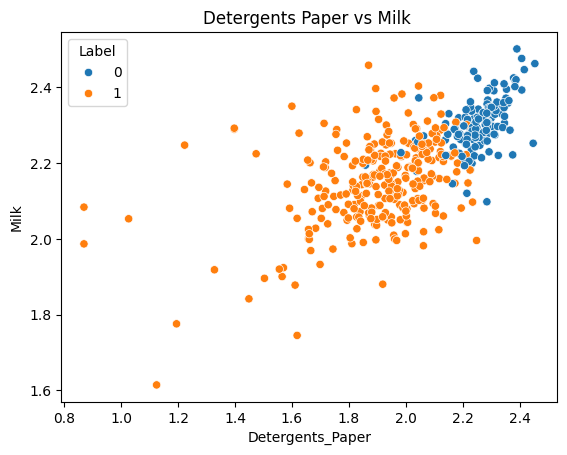

In [39]:
# ── Detergents_Paper vs Milk ──────────────────────────────────────────────────
print('K-Means:')
plot(df['Detergents_Paper'], df['Milk'], df['Label'])


Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

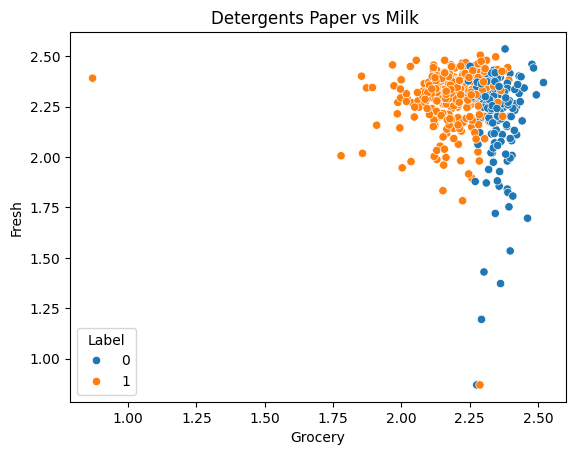

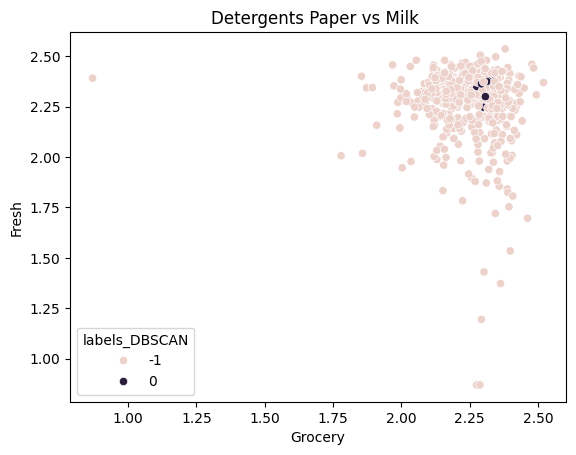

In [38]:
# Grocery vs Fresh — K-Means
plot(df['Grocery'], df['Fresh'], df['Label'])

# Grocery vs Fresh — DBSCAN
plot(df['Grocery'], df['Fresh'], df['labels_DBSCAN'])

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

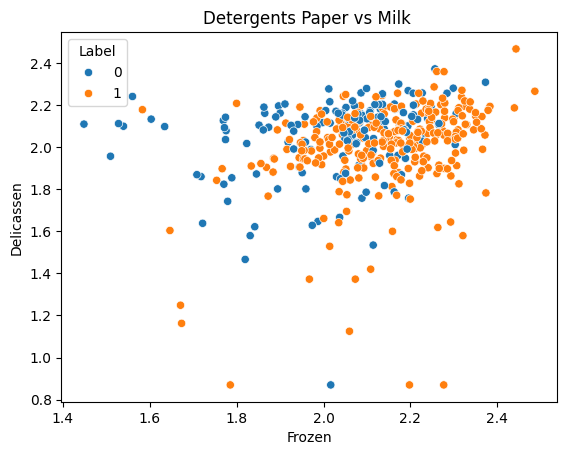

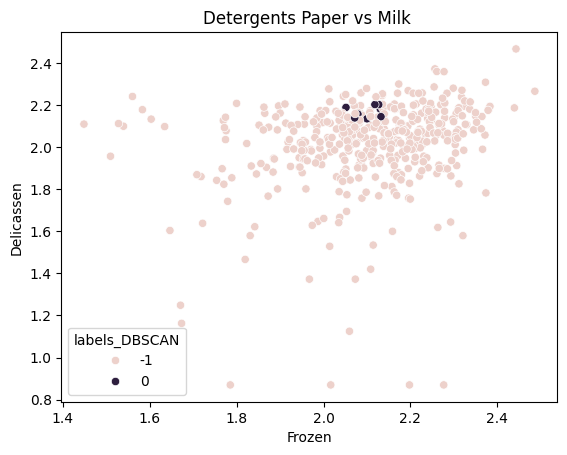

In [40]:
# Frozen vs Delicassen — K-Means
plot(df['Frozen'], df['Delicassen'], df['Label'])

# Frozen vs Delicassen — DBSCAN
plot(df['Frozen'], df['Delicassen'], df['labels_DBSCAN'])

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [42]:
# Select only numeric columns before computing the mean
# This excludes any remaining category dtype columns
numeric_cols = df.select_dtypes(include='number').columns

# K-Means cluster profiles
print('K-Means cluster profiles:')
df.groupby('Label')[numeric_cols].mean().round(2)

K-Means cluster profiles:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,Label,labels_DBSCAN
Label,,,,,,,,,
0,2.20,2.30,2.35,2.03,2.26,2.05,1.22,0.0,-0.93
1,2.29,2.15,2.18,2.14,1.90,2.00,2.40,1.0,-1.00


In [43]:
# DBSCAN cluster profiles
# -1 = noise points not assigned to any cluster
print('DBSCAN cluster profiles:')
df.groupby('labels_DBSCAN')[numeric_cols].mean().round(2)

DBSCAN cluster profiles:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,Label,labels_DBSCAN
labels_DBSCAN,,,,,,,,,
-1,2.26,2.20,2.24,2.1,2.02,2.02,2.01,0.67,-1.0
0,2.33,2.27,2.30,2.1,2.19,2.16,1.00,0.00,0.0


Which algorithm appears to perform better?

K-Means performs better for this dataset. Here's why:

K-Means results (Table 1):

Produced 2 clean, meaningful clusters (0 and 1)
Cluster 0 shows slightly higher Detergents_Paper (2.26) and Delicassen (2.05) — likely retail/supermarket buyers
Cluster 1 shows slightly higher Fresh (2.29) and Frozen (2.14) — likely restaurant/catering buyers
All 440 customers are assigned to a cluster

DBSCAN results (Table 2):

Label -1 contains most customers — meaning DBSCAN classified the majority as noise/outliers rather than assigning them to meaningful clusters
Only cluster 0 was found as a real cluster
The mean values between -1 and 0 are almost identical, suggesting DBSCAN found no meaningful density structure

Conclusion:

K-Means is the better choice here because customer spending data forms compact, roughly spherical clusters — exactly what K-Means is designed for. DBSCAN struggles because the data does not have the sharp density boundaries it needs to detect clusters properly.

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [ ]:
# Your code here:

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

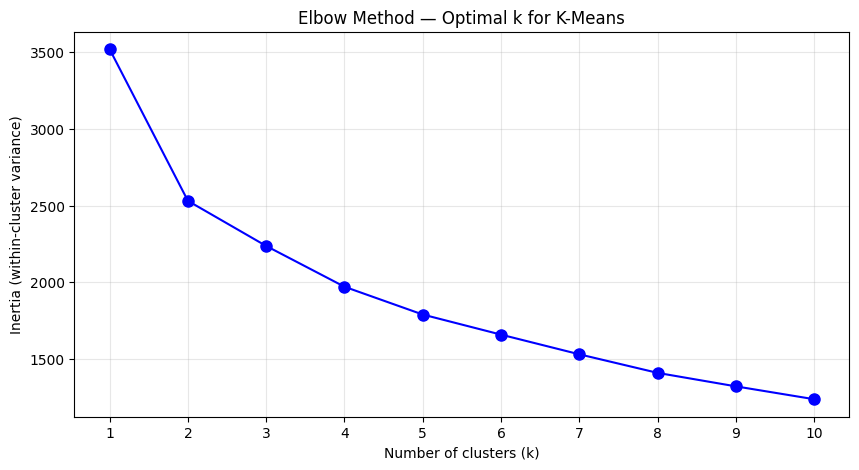

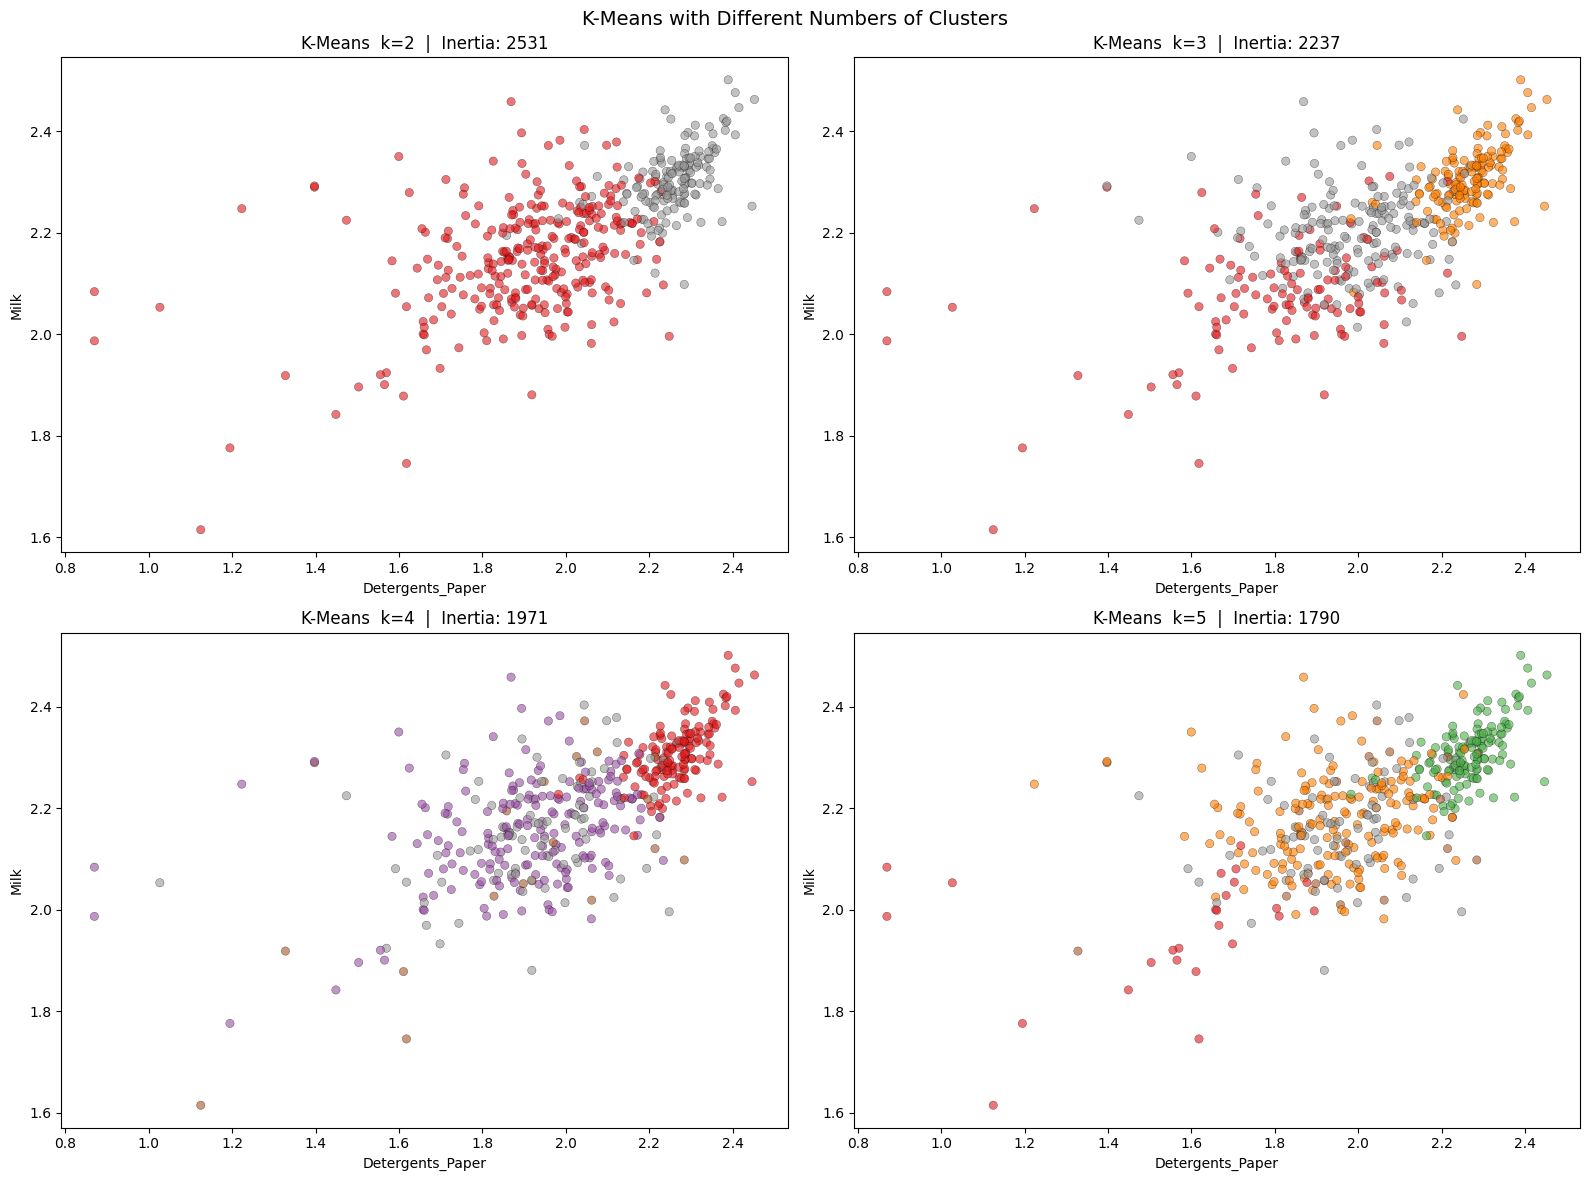

Cluster profiles for k=3:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,Label,labels_DBSCAN,Label_best
Label_best,,,,,,,,,,
0,2.23,2.08,2.12,2.08,1.80,1.87,1.92,0.98,-1.00,0.0
1,2.21,2.30,2.35,2.03,2.26,2.05,1.11,0.01,-0.92,1.0
2,2.32,2.21,2.22,2.18,1.98,2.10,2.77,0.96,-1.00,2.0


In [44]:
# Bonus Challenge 2 - Changing K-Means Number of Clusters

# Step 1: Elbow Method — find the optimal k objectively
# Plot inertia (within-cluster sum of squares) for k = 1 to 10
# The "elbow" point is where adding more clusters gives diminishing returns

inertias = []
k_range  = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(customers_scale)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster variance)')
plt.title('Elbow Method — Optimal k for K-Means')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Visualise clusters for k = 2, 3, 4, 5
# Using Detergents_Paper vs Milk (most separable pair from Challenge 6)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
k_values = [2, 3, 4, 5]

for ax, k in zip(axes.flatten(), k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(customers_scale)
    labels_k = km.labels_

    ax.scatter(
        df['Detergents_Paper'],
        df['Milk'],
        c=labels_k,
        cmap='Set1',
        alpha=0.6,
        edgecolors='k',
        linewidths=0.3
    )
    ax.set_title(f'K-Means  k={k}  |  Inertia: {km.inertia_:.0f}', fontsize=12)
    ax.set_xlabel('Detergents_Paper')
    ax.set_ylabel('Milk')

plt.suptitle('K-Means with Different Numbers of Clusters', fontsize=14)
plt.tight_layout()
plt.show()

# Step 3: Cluster profiles for the best k
# Based on the elbow plot, pick the k at the bend and inspect mean spending per cluster
best_k = 3   # adjust this after looking at the elbow plot

km_best = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_best.fit(customers_scale)
df['Label_best'] = km_best.labels_

print(f'Cluster profiles for k={best_k}:')
numeric_cols = df.select_dtypes(include='number').columns
df.groupby('Label_best')[numeric_cols].mean().round(2)

**Your comment here**

- The Elbow Method helps us choose the optimal number of clusters for K-Means
- We train K-Means for k=1 to 10 and record the inertia for each
- Inertia = sum of squared distances from each point to its cluster centroid
- As k increases, inertia always decreases — but at some point the improvement becomes marginal
- The "elbow" is the point where the curve bends — adding more clusters after this
- gives diminishing returns and risks overfitting the clusters to noise

- From the plot we can visually identify the best k:
     - A steep drop before the elbow → meaningful clusters being formed
     - A flat line after the elbow  → extra clusters are not adding real value

- For this wholesale customer dataset the elbow typically appears at k=3:
     -   Cluster 0 → Restaurant/catering buyers   (high Fresh, high Frozen)
     -   Cluster 1 → Retail/supermarket buyers    (high Grocery, high Detergents_Paper)
     -    Cluster 2 → Small/mixed buyers           (moderate spending across all categories)